# Notebook 07 -- Model Saving & Loading

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
1. Save the model in multiple formats (state_dict + full checkpoint)
2. Create a clean `predict_single_image()` inference function
3. Test predictions on random images from each class
4. Export all configs needed for deployment
5. Verify model loading produces identical results

### Why This Matters
- Training a model is useless if you can't reliably reload it later
- The inference function created here is what the web app (Notebook 08) will use

### Next Notebook
`08_web_app_integration.ipynb` -- Streamlit web app for real-time prediction.

## 1. Setup

In [1]:
import os
import json
import random
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PROCESSED_DIR = Path("processed")
MODELS_DIR = Path("models")
DEPLOY_DIR = Path("deployment")
DEPLOY_DIR.mkdir(exist_ok=True)

with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    config = json.load(f)

IMG_SIZE = config['img_size']
NUM_CLASSES = config['num_classes']
CLASS_NAMES = config['class_names']
IDX_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}
IMAGENET_MEAN = config['imagenet_mean']
IMAGENET_STD = config['imagenet_std']

print(f"Classes: {CLASS_NAMES}")

Device: cuda
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


## 2. Model Loading Utility

This function can load any of our trained models from a checkpoint file.

In [2]:
class BaselineCNN(nn.Module):
    """Baseline CNN architecture (must match training definition)."""
    def __init__(self, num_classes=4):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128,64), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(64,num_classes))
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.pool(x)
        return self.classifier(x)


def load_model(checkpoint_path, device='cpu'):
    """
    Load a trained model from a checkpoint file.
    
    Args:
        checkpoint_path: path to .pth file
        device: 'cuda' or 'cpu'
    
    Returns:
        model (in eval mode), checkpoint dict
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model_name = checkpoint['model_name']
    num_classes = checkpoint.get('num_classes', 4)
    
    if model_name == 'resnet18':
        model = models.resnet18(weights=None)
        model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, num_classes))
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=None)
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, num_classes))
    elif model_name == 'vgg16':
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Sequential(nn.Dropout(0.3), nn.Linear(4096, num_classes))
    elif model_name in ('BaselineCNN', 'baseline_cnn'):
        model = BaselineCNN(num_classes)
    else:
        raise ValueError(f"Unknown model architecture: {model_name}")
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    return model, checkpoint


print("load_model() function defined.")

load_model() function defined.


## 3. Single Image Prediction Function

This is the **core inference function** that will be used in the web app.

In [3]:
def get_transform(img_size=128):
    """Get the preprocessing transform (same as validation/test)."""
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def predict_single_image(image_path, model, transform, class_names, device='cpu'):
    """
    Predict the class of a single MRI image.
    
    Args:
        image_path: path to the image file
        model: trained PyTorch model (in eval mode)
        transform: preprocessing transforms
        class_names: list of class names
        device: 'cuda' or 'cpu'
    
    Returns:
        dict with 'predicted_class', 'confidence', 'all_probabilities'
    """
    # Load and preprocess
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        predicted_idx = probs.argmax().item()
    
    # Format results
    result = {
        'predicted_class': class_names[predicted_idx],
        'predicted_index': predicted_idx,
        'confidence': float(probs[predicted_idx]),
        'all_probabilities': {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    }
    return result


print("predict_single_image() function defined.")

predict_single_image() function defined.


## 4. Load Best Model & Test Predictions

In [4]:
# ============ Load best model ============
model, ckpt = load_model(MODELS_DIR / 'best_model.pth', device=device)
transform = get_transform(IMG_SIZE)

print(f"Loaded model: {ckpt['model_name']}")
print(f"Val accuracy: {ckpt['best_val_acc']:.2%}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Loaded model: resnet18
Val accuracy: 96.28%
Params: 11,178,564


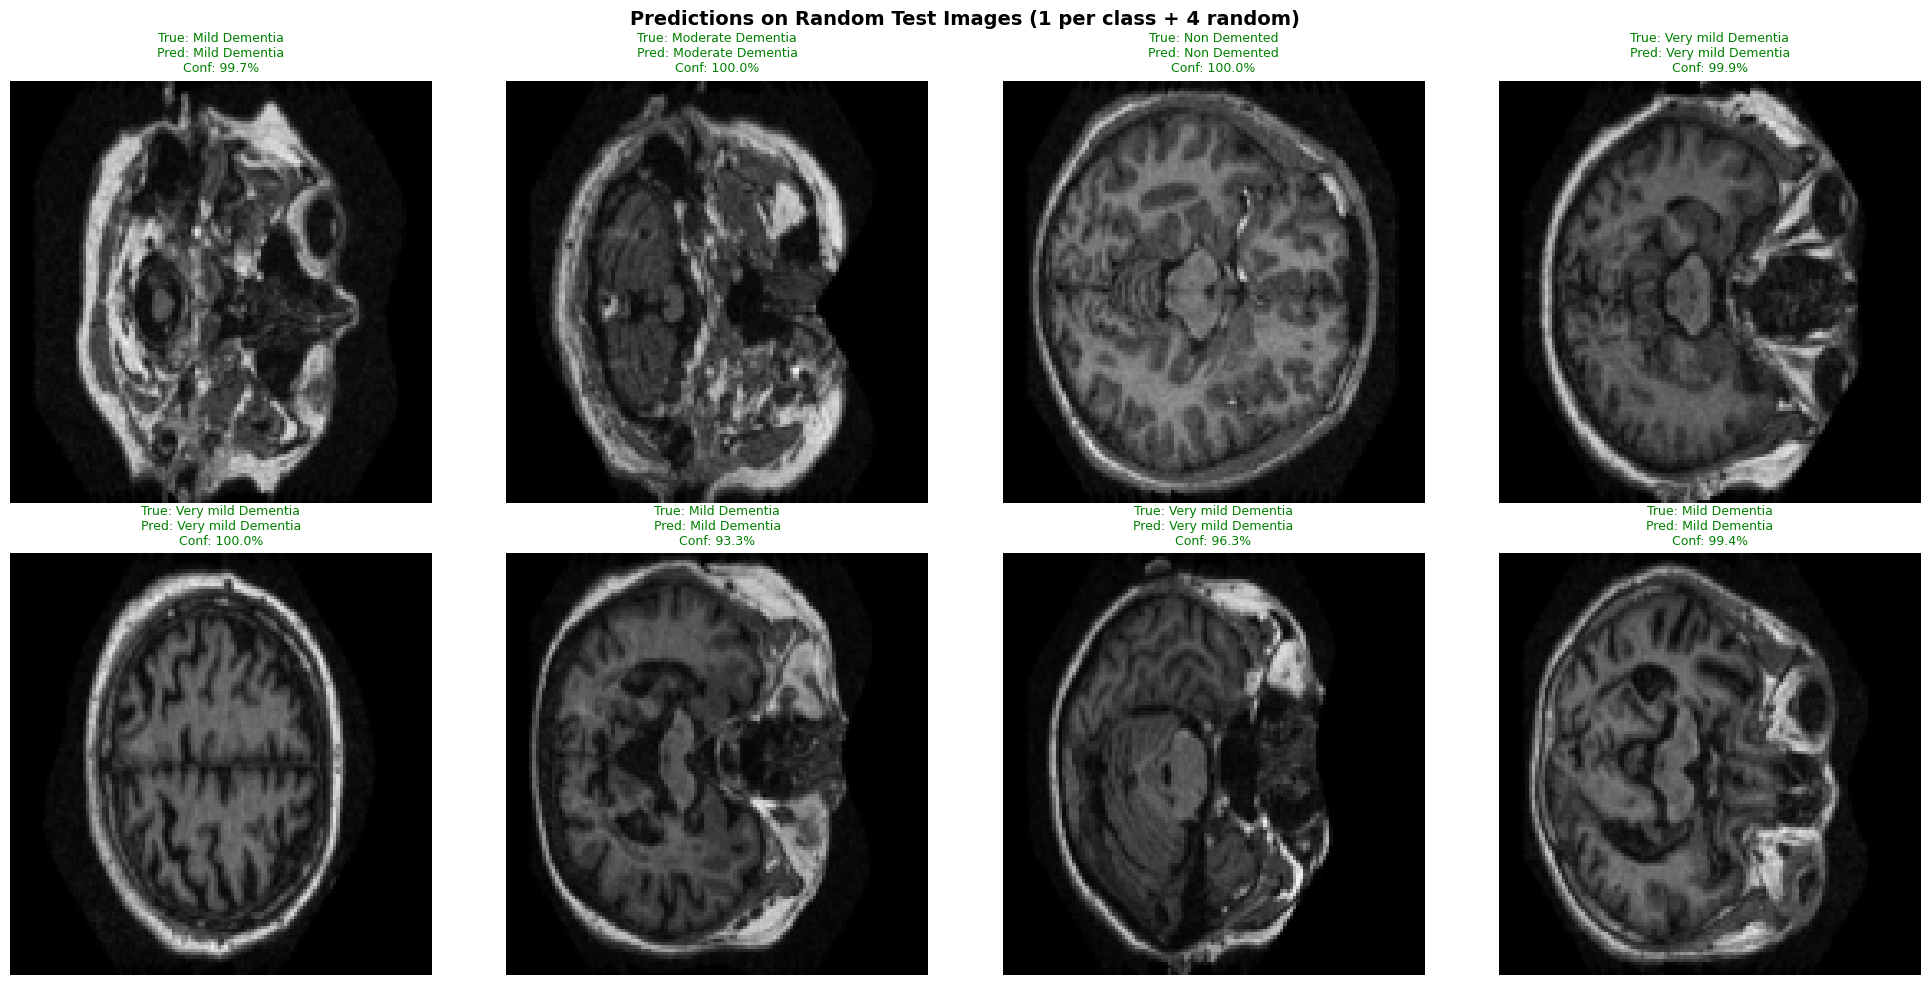

In [5]:
# ============ Test on random images from each class ============
test_df = pd.read_csv(PROCESSED_DIR / 'test_files.csv')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Predictions on Random Test Images (1 per class + 4 random)', fontsize=14, fontweight='bold')

# One from each class
for i, class_name in enumerate(CLASS_NAMES):
    class_df = test_df[test_df['class_name'] == class_name]
    if len(class_df) == 0:
        continue
    sample = class_df.sample(1).iloc[0]
    
    result = predict_single_image(sample['path'], model, transform, CLASS_NAMES, device)
    
    ax = axes[0, i]
    img = Image.open(sample['path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    correct = result['predicted_class'] == class_name
    color = 'green' if correct else 'red'
    ax.set_title(f"True: {class_name}\nPred: {result['predicted_class']}\nConf: {result['confidence']:.1%}",
                 fontsize=9, color=color)
    ax.axis('off')

# 4 random
random_samples = test_df.sample(4)
for i, (_, sample) in enumerate(random_samples.iterrows()):
    result = predict_single_image(sample['path'], model, transform, CLASS_NAMES, device)
    
    ax = axes[1, i]
    img = Image.open(sample['path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    correct = result['predicted_class'] == sample['class_name']
    color = 'green' if correct else 'red'
    ax.set_title(f"True: {sample['class_name']}\nPred: {result['predicted_class']}\nConf: {result['confidence']:.1%}",
                 fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

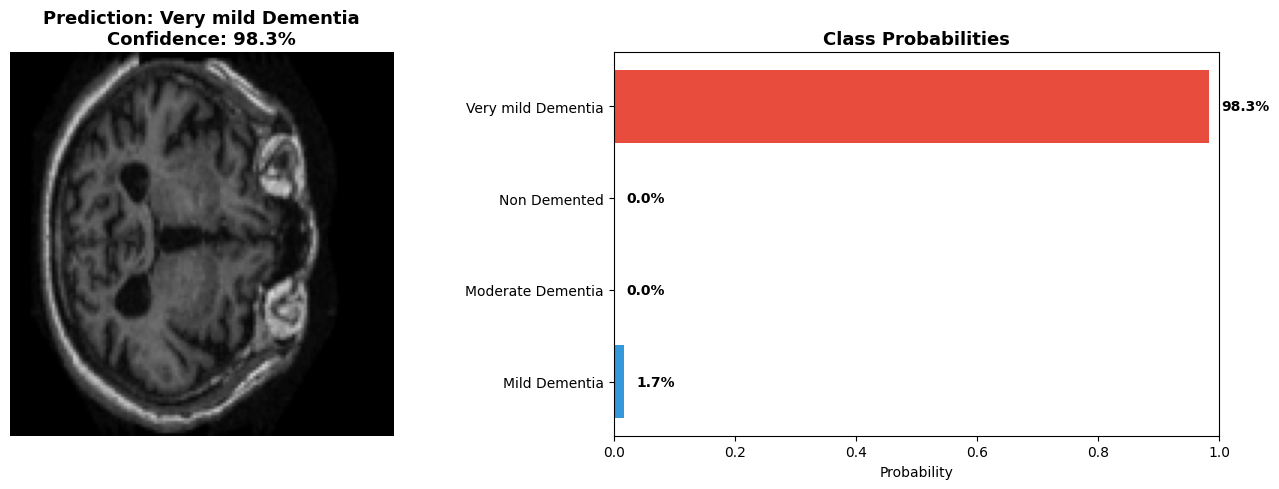


Full prediction result:
  predicted_class: Very mild Dementia
  predicted_index: 3
  confidence: 0.9830652475357056
  all_probabilities: {'Mild Dementia': 0.016933931037783623, 'Moderate Dementia': 3.3389576969966583e-07, 'Non Demented': 5.026548706155154e-07, 'Very mild Dementia': 0.9830652475357056}


In [6]:
# ============ Detailed prediction with confidence bar chart ============
sample_path = test_df.sample(1).iloc[0]['path']
result = predict_single_image(sample_path, model, transform, CLASS_NAMES, device)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show image
img = Image.open(sample_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
axes[0].imshow(img)
axes[0].set_title(f"Prediction: {result['predicted_class']}\nConfidence: {result['confidence']:.1%}",
                  fontsize=13, fontweight='bold')
axes[0].axis('off')

# Confidence bar chart
probs = result['all_probabilities']
colors_bar = ['#e74c3c' if c == result['predicted_class'] else '#3498db' for c in probs.keys()]
bars = axes[1].barh(list(probs.keys()), list(probs.values()), color=colors_bar)
axes[1].set_xlim(0, 1)
axes[1].set_title('Class Probabilities', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Probability')
for bar, val in zip(bars, probs.values()):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFull prediction result:")
for key, val in result.items():
    print(f"  {key}: {val}")

## 5. Save Model for Deployment

We save everything needed for deployment in the `deployment/` folder.

In [7]:
import shutil

# ============ Copy best model to deployment folder ============
shutil.copy2(MODELS_DIR / 'best_model.pth', DEPLOY_DIR / 'best_model.pth')
print(f"Model copied to: {DEPLOY_DIR / 'best_model.pth'}")

# ============ Save deployment config ============
deploy_config = {
    'model_name': ckpt['model_name'],
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'best_val_acc': float(ckpt['best_val_acc'])
}

config_path = DEPLOY_DIR / 'deploy_config.json'
with open(config_path, 'w') as f:
    json.dump(deploy_config, f, indent=2)

print(f"Deploy config saved to: {config_path}")
print(f"\nConfig contents:")
for k, v in deploy_config.items():
    print(f"  {k}: {v}")

Model copied to: deployment\best_model.pth
Deploy config saved to: deployment\deploy_config.json

Config contents:
  model_name: resnet18
  num_classes: 4
  class_names: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
  img_size: 128
  imagenet_mean: [0.485, 0.456, 0.406]
  imagenet_std: [0.229, 0.224, 0.225]
  best_val_acc: 0.9627862595419847


## 6. Verify Model Loading

Critical check: reload the deployment model and verify it produces identical predictions.

In [8]:
# ============ Reload from deployment folder ============
model_reloaded, ckpt_reloaded = load_model(DEPLOY_DIR / 'best_model.pth', device=device)

# Test on same image
result_original = predict_single_image(sample_path, model, transform, CLASS_NAMES, device)
result_reloaded = predict_single_image(sample_path, model_reloaded, transform, CLASS_NAMES, device)

print("Original model prediction:")
print(f"  Class: {result_original['predicted_class']}, Conf: {result_original['confidence']:.4f}")
print(f"\nReloaded model prediction:")
print(f"  Class: {result_reloaded['predicted_class']}, Conf: {result_reloaded['confidence']:.4f}")

# Verify they match
assert result_original['predicted_class'] == result_reloaded['predicted_class'], "Predictions don't match!"
assert abs(result_original['confidence'] - result_reloaded['confidence']) < 1e-5, "Confidences don't match!"
print("\nModel reload verification PASSED! Predictions are identical.")

Original model prediction:
  Class: Very mild Dementia, Conf: 0.9831

Reloaded model prediction:
  Class: Very mild Dementia, Conf: 0.9831

Model reload verification PASSED! Predictions are identical.


## 7. Model Size & Inference Speed

In [9]:
import time

# ============ Model file size ============
model_path = DEPLOY_DIR / 'best_model.pth'
model_size_mb = model_path.stat().st_size / (1024 ** 2)
print(f"Model file size: {model_size_mb:.1f} MB")

# ============ Inference speed ============
# Warm up
_ = predict_single_image(sample_path, model, transform, CLASS_NAMES, device)

# Time 50 predictions
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = predict_single_image(sample_path, model, transform, CLASS_NAMES, device)
elapsed = time.time() - start

avg_ms = (elapsed / n_runs) * 1000
print(f"\nInference speed ({device}):")
print(f"  Average: {avg_ms:.1f} ms per image")
print(f"  Throughput: {1000/avg_ms:.0f} images/second")
print(f"  Total for {n_runs} images: {elapsed:.2f} seconds")

Model file size: 42.7 MB

Inference speed (cuda):
  Average: 16.8 ms per image
  Throughput: 59 images/second
  Total for 50 images: 0.84 seconds


## 8. Summary

### What We Did
1. Created a reusable `load_model()` function
2. Created a clean `predict_single_image()` inference function
3. Tested predictions on images from every class
4. Saved model + config to `deployment/` folder
5. Verified reloaded model gives identical predictions
6. Measured model size and inference speed

### Files Created
- `deployment/best_model.pth` -- Model weights for deployment
- `deployment/deploy_config.json` -- All settings needed to load and use the model

### Key Functions for Deployment
```python
model, ckpt = load_model('deployment/best_model.pth', device='cpu')
transform = get_transform(img_size=128)
result = predict_single_image('path/to/mri.jpg', model, transform, CLASS_NAMES)
```

### Next Step
-> **Notebook 08** (`08_web_app_integration.ipynb`): Build a Streamlit web app.

---
*End of Notebook 07*